Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
df1 = pd.read_csv('C:/Users/MSIS/Downloads/AML/MLLabprojects/data/data-1.csv')
df2 = pd.read_csv('C:/Users/MSIS/Downloads/AML/MLLabprojects/data/data-2.csv')

print("Data 1 Shape:", df1.shape)
print("Data 2 Shape:", df2.shape)

Data 1 Shape: (5, 4)
Data 2 Shape: (6, 5)


Drop Constant Features

In [ ]:
# Remove zero-variance (constant) features like 'offer' and 'online payment'
non_constant_cols1 = [col for col in df1.columns if df1[col].nunique() > 1]
constant_cols1 = list(set(df1.columns) - set(non_constant_cols1))

print(f"Dropped Constant Features in Data 1: {constant_cols1}")

df1_clean = df1[non_constant_cols1]

Dropped Constant Features in Data 1: ['offer', 'online payment']


Correlation heatmap + Feature Selection

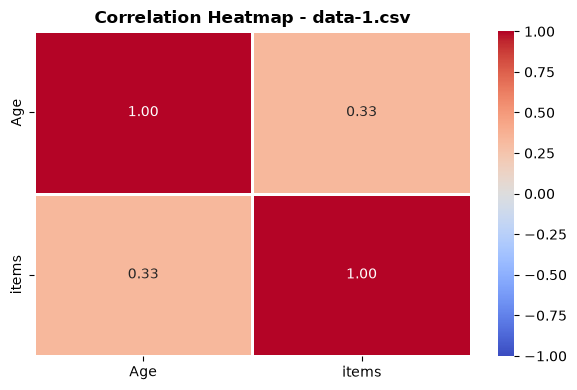

Correlation with Target ('items'):
Age    0.33076
Name: items, dtype: float64

Final Selected Features for Data 1: ['Age']


In [ ]:
# Compute correlation matrix for data-1
corr1 = df1_clean.corr()

# Plot Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr1, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.8)
plt.title('Correlation Heatmap - data-1.csv', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Show target correlation
print("Correlation with Target ('items'):")
print(corr1['items'].drop('items'))

# Selected features for data-1
selected_features1 = [col for col in df1_clean.columns if col != 'items']
print(f"\nFinal Selected Features for Data 1: {selected_features1}")

Compute correlation matrix and plot heatmap

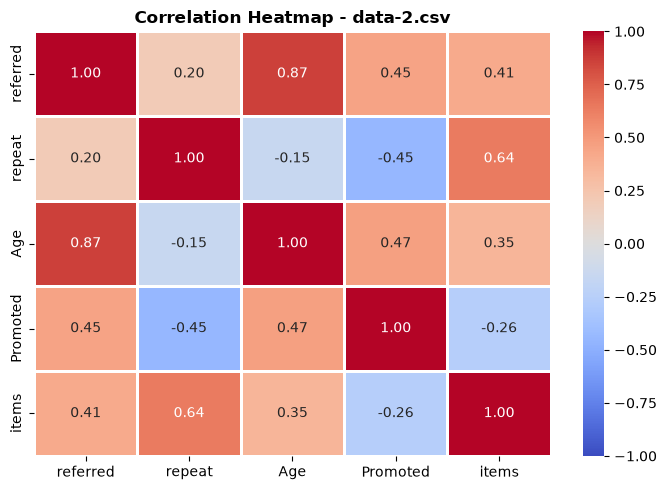

Feature Correlation with Target ('items'):
repeat      0.6404
referred    0.4076
Age         0.3479
Promoted   -0.2604
Name: items, dtype: float64


In [ ]:
# Compute correlation matrix for data-2
corr2 = df2.corr()

# Plot Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr2, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.8)
plt.title('Correlation Heatmap - data-2.csv', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Show target correlation ranked by strength
target_corr2 = corr2['items'].drop('items').sort_values(key=abs, ascending=False)
print("Feature Correlation with Target ('items'):")
print(target_corr2.round(4))

Multicollinearity and feature selection

In [ ]:
# Filter out highly correlated redundant features (Threshold = 0.8)
corr_threshold = 0.8
feature_cols2 = [col for col in df2.columns if col != 'items']
feat_corr2 = df2[feature_cols2].corr().abs()

# Extract upper triangle of correlation matrix to find pairs
upper_tri = feat_corr2.where(np.triu(np.ones(feat_corr2.shape), k=1).astype(bool))
collinear_to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)]

print(f"Dropped due to Multicollinearity (> {corr_threshold}): {collinear_to_drop}")

# Final feature set selection
selected_features2 = [col for col in feature_cols2 if col not in collinear_to_drop]
print(f"Final Selected Features for Data 2: {selected_features2}")

Dropped due to Multicollinearity (> 0.8): ['Age']
Final Selected Features for Data 2: ['referred', 'repeat', 'Promoted']


Output final clean datasets

In [ ]:
# Save/Extract final datasets with selected features + target variable
df1_final = df1_clean[['items'] + selected_features1]
df2_final = df2[['items'] + selected_features2]

print("--- Data 1 Final Columns ---")
print(df1_final.columns.tolist())

print("\n--- Data 2 Final Columns ---")
print(df2_final.columns.tolist())

--- Data 1 Final Columns ---
['items', 'Age']

--- Data 2 Final Columns ---
['items', 'referred', 'repeat', 'Promoted']
